# RappiPlus: desempeño comercial y conciliación de KPIs
**Mario Alberto Vivero · Proyecto académico**

Revisión reproducible de los tres CSV aportados. Las capturas originales de Power BI se conservan como evidencia histórica; sus cifras no coinciden con esta versión de los datos. No se modifica el archivo fuente ni se fabrica un PBIX.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd()
if not (ROOT/'data').is_dir(): ROOT = ROOT.parent
orders = pd.read_csv(ROOT/'data/orders_clean.csv')
catalog = pd.read_csv(ROOT/'data/catalog_clean.csv')
marketing = pd.read_csv(ROOT/'data/marketing_clean.csv')
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'], errors='raise')
marketing['fecha'] = pd.to_datetime(marketing['fecha'], errors='raise')
for name, frame in [('orders',orders),('catalog',catalog),('marketing',marketing)]:
    print(name, frame.shape, '\nNulos:\n', frame.isna().sum().to_string())
print('Pedidos repetidos:', orders['id_pedido'].duplicated().sum())
print('Filas duplicadas de marketing:', marketing.duplicated().sum())
print('Rango pedidos:', orders['fecha_hora_pedido'].min(), orders['fecha_hora_pedido'].max())
print('Rango marketing:', marketing['fecha'].min(), marketing['fecha'].max())


orders (18713, 12) 
Nulos:
 id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  218
dispositivo            16
fuente_referencia      21
nombre_producto        21
categoria_producto     21
cantidad                0
precio_unitario         0
monto_descuento         0
monto_total             0
catalog (7, 4) 
Nulos:
 nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
marketing (1620, 5) 
Nulos:
 fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
Pedidos repetidos: 0
Filas duplicadas de marketing: 0
Rango pedidos: 2025-01-01 00:00:00 2025-06-30 00:00:00
Rango marketing: 2025-01-01 00:00:00 2025-06-29 00:00:00


## Integración y definición de métricas
La unión usa producto y valida cardinalidad muchos-a-uno. Marketing se suma por separado: unir cada gasto a cada pedido multiplicaría importes. Se usa la categoría del catálogo para evitar la diferencia ortográfica Electronica/Electrónica.

Los costos desconocidos permanecen nulos. El resultado con costos conocidos es provisional, no beneficio neto: faltan costos de 21 pedidos y otros gastos operativos. La moneda no se confirmó; los importes se tratan como unidades monetarias del ejercicio.


In [2]:
assert catalog['nombre_producto'].notna().all()
assert catalog['nombre_producto'].is_unique
x = orders.merge(catalog[['nombre_producto','categoria_producto','costo_unitario']],
    on='nombre_producto', how='left', validate='many_to_one', suffixes=('_orden','_catalogo'))
assert len(x) == len(orders)
x['costo_producto'] = x['cantidad'] * x['costo_unitario']
x['beneficio_bruto_conocido'] = x['monto_total'] - x['costo_producto']
revenue = x['monto_total'].sum()
costo_conocido = x['costo_producto'].sum(min_count=1)
gasto_marketing = marketing['gasto'].sum()
sin_costo = x['costo_unitario'].isna()
kpis = pd.Series({
    'Revenue': revenue,
    'Costo de producto conocido': costo_conocido,
    'Marketing total': gasto_marketing,
    'Resultado provisional antes de costos faltantes y otros gastos': revenue-costo_conocido-gasto_marketing,
    'Ticket promedio': revenue/x['id_pedido'].nunique(),
    'Unidades por pedido': x['cantidad'].sum()/x['id_pedido'].nunique(),
    'Pedidos sin costo identificable': int(sin_costo.sum()),
    'Revenue de pedidos sin costo': x.loc[sin_costo,'monto_total'].sum()
})
print(kpis.to_string(float_format=lambda v: f'{v:,.2f}'))
print('Beneficio bruto solo en pedidos con costo:', x['beneficio_bruto_conocido'].sum())
print('No confundir suma de márgenes por fila con revenue total menos costos conocidos.')


Revenue                                                          48,768,784.27
Costo de producto conocido                                       41,832,828.49
Marketing total                                                   2,871,843.53
Resultado provisional antes de costos faltantes y otros gastos    4,064,112.25
Ticket promedio                                                       2,606.14
Unidades por pedido                                                       8.82
Pedidos sin costo identificable                                          21.00
Revenue de pedidos sin costo                                          6,441.07
Beneficio bruto solo en pedidos con costo: 6929514.709999999
No confundir suma de márgenes por fila con revenue total menos costos conocidos.


## Concentración y sensibilidad
Se señalan pedidos con más de 100 unidades como criterio exploratorio, no como regla de eliminación validada. El CSV conserva todos los pedidos. Diez registros de 10000–20000 unidades concentran 86.83% del revenue: cualquier conclusión comercial depende fuertemente de su validez.


In [3]:
large = x['cantidad'] > 100
print('Pedidos destacados:', int(large.sum()))
print('Revenue destacado:', x.loc[large,'monto_total'].sum())
print('Porcentaje de revenue:', 100*x.loc[large,'monto_total'].sum()/revenue)
print('Revenue sin esos pedidos, sensibilidad:', x.loc[~large,'monto_total'].sum())
print(x.loc[large,['id_pedido','cantidad','monto_total','beneficio_bruto_conocido']].to_string(index=False))
print('Unidades por producto:\n', x.groupby('nombre_producto',dropna=False)['cantidad'].sum().sort_values(ascending=False))


Pedidos destacados: 10
Revenue destacado: 42344700.0
Porcentaje de revenue: 86.82746685987874
Revenue sin esos pedidos, sensibilidad: 6424084.2700000005
 id_pedido  cantidad  monto_total  beneficio_bruto_conocido
order_3521   10000.0     431400.0                -2375400.0
order_3522   10000.0    2805500.0                   -1300.0
order_3586   10000.0    4903500.0                 2096700.0
order_3643   10000.0    2381500.0                 -425300.0
order_3656   20000.0    5953200.0                  339600.0
order_3668   20000.0    6966200.0                 1352600.0
order_3689   10000.0     876900.0                -1929900.0
order_3722   20000.0    8840200.0                 3226600.0
order_3726   20000.0    5817000.0                  203400.0
order_3748   10000.0    3369300.0                  562500.0
Unidades por producto:
 nombre_producto
Laptop-Gaming-16GB      142752.0
Vacuum-Pro-Black          4252.0
Sneakers-Urban-42         4226.0
Jacket-Winter-M           4212.0
Blender-XL-Red 

## Evolución mensual y acumulado
Se separa el ingreso mensual del acumulado anual. Para estos importes positivos, el acumulado crece de enero a junio. La gráfica original etiquetada YTD baja entre meses y se parece al ingreso mensual; requiere revisar su medida y contexto de fechas en el PBIX.


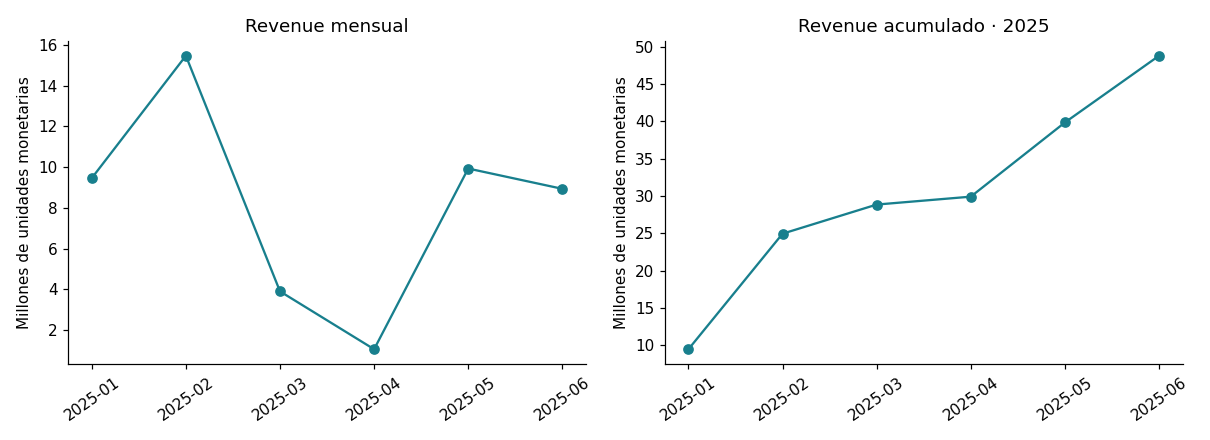

                       revenue  acumulado_2025
fecha_hora_pedido                             
2025-01             9462279.62      9462279.62
2025-02            15474855.76     24937135.38
2025-03             3900777.95     28837913.33
2025-04             1058524.01     29896437.34
2025-05             9934443.42     39830880.76
2025-06             8937903.51     48768784.27


In [4]:
monthly = x.groupby(x['fecha_hora_pedido'].dt.to_period('M'))['monto_total'].sum()
print(pd.DataFrame({'revenue':monthly, 'acumulado_2025':monthly.cumsum()}).to_string())
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,series,title in [(axes[0],monthly,'Revenue mensual'),(axes[1],monthly.cumsum(),'Revenue acumulado · 2025')]:
    ax.plot(series.index.astype(str),series.values/1e6, marker='o',color='#187f8d')
    ax.set(title=title,ylabel='Millones de unidades monetarias')
    ax.tick_params(axis='x',rotation=35)
    ax.spines[['top','right']].set_visible(False)
fig.tight_layout()
fig.savefig(ROOT/'images/revenue_validado.png',dpi=160)
plt.show()


In [5]:
summary = x.groupby('categoria_producto_catalogo',dropna=False).agg(
    revenue=('monto_total','sum'),
    beneficio_bruto_conocido=('beneficio_bruto_conocido',lambda s:s.sum(min_count=1)),
    pedidos=('id_pedido','nunique'))
print(summary.to_string())
print('Marketing por canal (incluye sin canal):')
print(marketing.groupby('canal',dropna=False)['gasto'].sum().to_string())
assert abs(marketing.groupby('canal',dropna=False)['gasto'].sum().sum()-gasto_marketing)<.01


                                 revenue  beneficio_bruto_conocido  pedidos
categoria_producto_catalogo                                                
Electrónica                  44457427.06                4293218.39     6141
Hogar                         2146337.11                1347820.47     6251
Moda                          2158579.03                1288475.85     6300
NaN                              6441.07                       NaN       21
Marketing por canal (incluye sin canal):
canal
organic        913533.01
paid_search    863088.21
social         918043.21
NaN            177179.10


## Decisiones propuestas

1. Conciliar Power BI con la versión de CSV usada y una definición explícita de profit. Revenue de 48.77 millones y ticket de 2606.14 corresponden al CSV adjunto, no a las tarjetas históricas de 51.99 millones y 2.08 mil.
2. Revisar los diez pedidos extremos antes de justificar compras de inventario o inversión basadas en el liderazgo de Electrónica. Laptop suma 142752 unidades en estos CSV, no 150000+.
3. Completar producto/costo en 21 pedidos y canal en 101 registros de marketing; conservar categorías sin dato para que las sumas por segmento concilien.
4. Revisar filtros, calendario y acumulado del dashboard. Sin el PBIX no se verifican medidas DAX, relaciones ni navegación interactiva.

El notebook revisado histórico calculaba 4.064 millones restando costos conocidos del revenue completo. Esa cantidad sigue siendo provisional. El conjunto limpio proviene de un filtro de consistencia exacta de importes que excluyó muchas filas; sin los datos brutos no puede auditarse si eran errores reales o diferencias de redondeo.
